In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from integral_functions.weight_functions import get_weights
from integral_functions.methods.inducing_points import get_discretizations, midpoint_to_disc
from numpy.typing import NDArray
from scipy.special import expit
from scipy.integrate import quad
from sklearn.metrics import mean_absolute_error, mean_squared_error
import statsmodels.api as sm

from regmod.models.binomial import BinomialModel
from regmod.parameter import Parameter
from regmod.variable import Variable
# For more Cython info on the import statement, visit the link: https://stackoverflow.com/questions/7508803/how-do-i-import-function-from-pyx-file-in-python

from integral_functions.methods.inducing_points import get_discretizations
from integral_functions.simulation.age_distribution import age_distribution
from integral_functions.simulation.death_rate import death_rate_function, expit_death_rate_function, func1, func2, func3
from integral_functions.simulation.sampling import sample_probability_of_death
from integral_functions.simulation.age_intervals import bounded_intervals_generator, int_bounded_intervals_generator, pop_density_generator
from integral_functions.simulation.integrate_functions import integrate_cov, integrate_denom

In [92]:
low_age = 0
high_age = 95
age_mid = 35

c1 = 0.001
c2 = 1
c3 = 0.0017

grid_points = np.arange(start=(low_age + 0.5), stop=(high_age + 0.5), step=1)
discretizations = get_discretizations(0,95, grid_points=grid_points)
population_list = []
for i in range(1,len(discretizations)):
    integral_over_interval = integrate_denom(age_distribution, discretizations[i-1], discretizations[i], age_mid=age_mid)
    population_list.append(integral_over_interval)
population_densities = np.array(population_list)
# population_densities /= np.sum(population_densities)
# My construction of this right now implies that we want population_densities to be equal in shape to grid_points. Basically we want the
# age density to be as fine as the number of grid points we have. I think this is something we can control.

#### Uniform 1-year age groups

In [110]:
# range for each sample group
np.random.seed(0)
num_groups = 1000
age_interval_lb = 20
age_interval_ub = 30
age_ranges = int_bounded_intervals_generator(low_age, high_age, num_groups, age_interval_lb, age_interval_ub)
df = pd.DataFrame(
    dict(
        age_start=age_ranges[0],
        age_end=age_ranges[1],
    )
)

# sample size for each sample group
df["sample_size"] = np.random.randint(low=10, high=100, size=num_groups)


df["obs"] = df.apply(
    lambda row: sample_probability_of_death(
        row.iloc[0],
        row.iloc[1],
        row.iloc[2],
        age_distribution,
        expit_death_rate_function,
        prob_args = {"c1": c1}
    ),
    axis=1,
)

# add grid_points: here I'm doing this on integers (and hence use arange). We can change
# this to np.linspace() for when we are not using integers. I'm just using integers because
# it felt like it would make more sense to me.
df["grid_points_with_indices"] = df.apply(
    lambda row: np.intersect1d(
        ar1=grid_points[grid_points >= row.iloc[0]],
        ar2=grid_points[grid_points <= row.iloc[1]],
        return_indices=True
    ),
    axis=1
)

df[["grid_points", "indices_left", "indices_right"]] = df["grid_points_with_indices"].apply(pd.Series)

df = df.drop(columns=["grid_points_with_indices"])

# Get population densities
df["pop_density"] = df.apply(
    lambda row: population_densities[row.loc["indices_right"]],
    axis=1
)

# Get weights
df["weights"] = df.apply(
    lambda row: get_weights(
        lb=row.iloc[0],
        ub=row.iloc[1],
        population_density=row.iloc[-1],
        grid_points=row.iloc[4],
    ),
    axis=1
)

# # Get function evaluations
df["function_evals1"] = df["grid_points"].apply(
    lambda row: np.array([func1(x) for x in row])
)
df["function_evals2"] = df["grid_points"].apply(
    lambda row: np.array([func2(x) for x in row])
)
df["function_evals3"] = df["grid_points"].apply(
    lambda row: np.array([func3(x) for x in row])
)

# Get covs columns
df["cov1"] = df.apply(
    lambda row: np.dot(row.weights, row.function_evals1),
    axis=1
)
df["cov2"] = df.apply(
    lambda row: np.dot(row.weights, row.function_evals2),
    axis=1
)
df["cov3"] = df.apply(
    lambda row: np.dot(row.weights, row.function_evals3),
    axis=1
)

# df["denom"] = df.apply(
#     lambda row: integrate_denom(
#         density=age_distribution,
#         age_start=row.iloc[0],
#         age_end=row.iloc[1],
#         age_mid=age_mid
#     ),
#     axis=1,
# )
df["denom"] = df.apply(
    lambda row: np.sum(row.pop_density),
    axis=1
)

df["cov1"] /= df["denom"]
df["cov2"] /= df["denom"]
df["cov3"] /= df["denom"]

# Get constructed outcomes
df["outcomes"] = expit((c1 * df["cov1"] + c2 * df["cov2"] + c3 * df["cov3"]))

# df = df.loc[:, [x for x in df.columns if x not in ("grid_points", "pop_in_each_bin", "weights", "function_evals1", "function_evals2", "function_evals3")]]

In [111]:
df.head()

,age_start,age_end,sample_size,obs,grid_points,indices_left,indices_right,pop_density,weights,function_evals1,function_evals2,function_evals3,cov1,cov2,cov3,denom,outcomes
0,44,67,60,0.166667,"[44.5, 45.5, 46.5, 47.5, 48.5, 49.5, 50.5, 51....","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 5...","[28.80327039814816, 28.092137064814825, 27.389...","[28.80327039814816, 28.092137064814825, 27.389...","[44.5, 45.5, 46.5, 47.5, 48.5, 49.5, 50.5, 51....","[-6.670832032063167, -6.745368781616021, -6.81...","[1980.25, 2070.25, 2162.25, 2256.25, 2352.25, ...",54.245309,-7.351842,2985.295176,498.300708,0.097740
1,47,67,54,0.092593,"[47.5, 48.5, 49.5, 50.5, 51.5, 52.5, 53.5, 54....","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 5...","[26.696537064814823, 26.012070398148154, 25.33...","[26.696537064814823, 26.012070398148154, 25.33...","[47.5, 48.5, 49.5, 50.5, 51.5, 52.5, 53.5, 54....","[-6.892024376045111, -6.96419413859206, -7.035...","[2256.25, 2352.25, 2450.25, 2550.25, 2652.25, ...",56.029093,-7.475616,3171.755099,414.015408,0.116335
2,64,92,94,0.670213,"[64.5, 65.5, 66.5, 67.5, 68.5, 69.5, 70.5, 71....","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 7...","[16.26949262037038, 15.736137064814823, 15.211...","[16.26949262037038, 15.736137064814823, 15.211...","[64.5, 65.5, 66.5, 67.5, 68.5, 69.5, 70.5, 71....","[-8.031189202104505, -8.093207028119323, -8.15...","[4160.25, 4290.25, 4422.25, 4556.25, 4692.25, ...",75.303301,-8.666534,5730.056662,283.057393,0.759486
3,9,37,62,0.016129,"[9.5, 10.5, 11.5, 12.5, 13.5, 14.5, 15.5, 16.5...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20...","[30.386666666666663, 31.586666666666662, 32.70...","[30.386666666666663, 31.586666666666662, 32.70...","[9.5, 10.5, 11.5, 12.5, 13.5, 14.5, 15.5, 16.5...","[-3.082207001484488, -3.24037034920393, -3.391...","[90.25, 110.25, 132.25, 156.25, 182.25, 210.25...",23.281981,-4.750826,603.589112,1042.469141,0.024093
4,21,42,35,0.000000,"[21.5, 22.5, 23.5, 24.5, 25.5, 26.5, 27.5, 28....","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 3...","[39.50666666666666, 39.74666666666666, 39.9066...","[39.50666666666666, 39.74666666666666, 39.9066...","[21.5, 22.5, 23.5, 24.5, 25.5, 26.5, 27.5, 28....","[-4.636809247747852, -4.743416490252569, -4.84...","[462.25, 506.25, 552.25, 600.25, 650.25, 702.2...",31.042816,-5.545576,999.230081,778.734937,0.021545


In [112]:
model_discrete_1 = BinomialModel(
    y="obs",
    weights="sample_size",
    df=df,
    params=[Parameter("p", [Variable(f"cov{i + 1}") for i in range(3)], inv_link="expit")],
)

In [113]:
model_discrete_1.fit()

In [114]:
model_discrete_1.opt_result.x

array([8.22037043e-02, 1.29587599e+00, 1.03756597e-03])

In [115]:
df_pred = pd.DataFrame(
    dict(age_mid=np.linspace(low_age, high_age, 101))
)
df_pred["cov1"] = func1(df_pred["age_mid"])
df_pred["cov2"] = func2(df_pred["age_mid"])
df_pred["cov3"] = func3(df_pred["age_mid"])
df_pred = model_discrete_1.predict(df_pred)
df_pred["p_true"] = expit_death_rate_function(df_pred["age_mid"], c1=c1)

In [116]:
df_pred

,age_mid,cov1,cov2,cov3,p,p_true
0,0.00,0.00,-0.000000,0.0000,0.500000,0.500000
1,0.95,0.95,-0.974679,0.9025,0.234328,0.274443
2,1.90,1.90,-1.378405,3.6100,0.164337,0.202560
3,2.85,2.85,-1.688194,8.1225,0.125102,0.158219
4,3.80,3.80,-1.949359,14.4400,0.099861,0.127749
...,...,...,...,...,...,...
96,91.20,91.20,-9.549869,8317.4400,0.977055,0.990815
97,92.15,92.15,-9.599479,8491.6225,0.981034,0.992814
98,93.10,93.10,-9.648834,8667.6100,0.984368,0.994399
99,94.05,94.05,-9.697938,8845.4025,0.987152,0.995650


Text(0.5, 1.0, 'Discrete weights uniform spacing = 1')

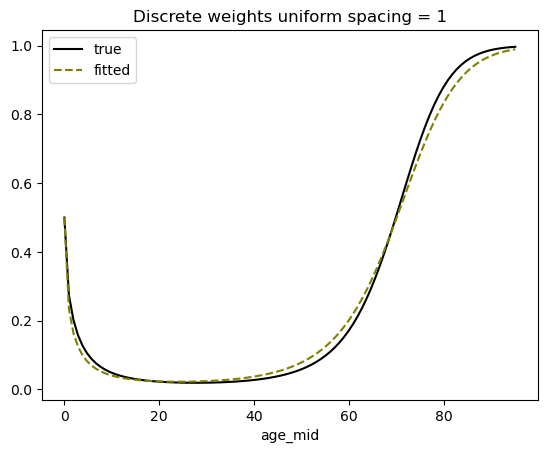

In [117]:
fig, ax = plt.subplots()
ax.plot(df_pred["age_mid"], df_pred["p_true"], color="k", label="true")
ax.plot(df_pred["age_mid"], df_pred["p"], color="olive", linestyle="--", label="fitted")
ax.legend()
ax.set_xlabel("age_mid")
# ax.set_yscale("log")
plt.title("Discrete weights uniform spacing = 1")

# for _, row in df.iterrows():
#     ax.plot([row["age_start"], row["age_end"]], [row["obs"]]*2, color="grey", alpha=0.2)

#### Uniform 5-year age groups

In [66]:
low_age = 0
high_age = 95
age_mid = 35

c1 = 0.001
c2 = 1
c3 = 0.0017

grid_points = np.arange(start=(low_age + 2.5), stop=(high_age + 0.5), step=5)
population_densities = np.array([age_distribution(grid_point, age_mid=age_mid) for grid_point in grid_points])
population_densities /= np.sum(population_densities)
# My construction of this right now implies that we want population_densities to be equal in shape to grid_points. Basically we want the
# age density to be as fine as the number of grid points we have. I think this is something we can control.

In [67]:
grid_points

array([ 2.5,  7.5, 12.5, 17.5, 22.5, 27.5, 32.5, 37.5, 42.5, 47.5, 52.5,
       57.5, 62.5, 67.5, 72.5, 77.5, 82.5, 87.5, 92.5])

In [68]:
population_densities

array([0.04446647, 0.0624782 , 0.07598701, 0.08499287, 0.08949581,
       0.08949581, 0.08499287, 0.07661679, 0.068111  , 0.06010553,
       0.05260039, 0.04559558, 0.03909109, 0.03308693, 0.0275831 ,
       0.02257959, 0.0180764 , 0.01407354, 0.01057101])

In [16]:
# range for each sample group
np.random.seed(0)
num_groups = 1000
age_interval_lb = 20
age_interval_ub = 30
age_ranges = int_bounded_intervals_generator(low_age, high_age, num_groups, age_interval_lb, age_interval_ub)
df5 = pd.DataFrame(
    dict(
        age_start=age_ranges[0],
        age_end=age_ranges[1],
    )
)

# sample size for each sample group
df5["sample_size"] = np.random.randint(low=10, high=100, size=num_groups)


df5["obs"] = df5.apply(
    lambda row: sample_probability_of_death(
        row.iloc[0],
        row.iloc[1],
        row.iloc[2],
        age_distribution,
        expit_death_rate_function,
        prob_args= {"c1": c1}
    ),
    axis=1,
)

# add grid_points: here I'm doing this on integers (and hence use arange). We can change
# this to np.linspace() for when we are not using integers. I'm just using integers because
# it felt like it would make more sense to me.
df5["grid_points"] = df5.apply(
    lambda row: np.arange(
        start=row.iloc[0] + 2.5,
        stop=row.iloc[1],
        step=5 # 1 here tells us the uniform grid size.
    ),
    axis=1
)

# Get population densities
df5["pop_in_each_bin"] = df5["sample_size"] / (df5["age_end"] - df5["age_start"])
df5["pop_density"] = df5["pop_in_each_bin"] / df5["sample_size"]

# Get weights
# Had to turn off assert here.
df5["weights"] = df5.apply(
    lambda row: get_weights(
        lb=row.iloc[0],
        ub=row.iloc[1],
        population_density=row.iloc[-1],
        grid_points=row.iloc[4],
    ),
    axis=1
)

# Get function evaluations
df5["function_evals1"] = df5["grid_points"].apply(
    lambda row: np.array([func1(x) for x in row])
)
df5["function_evals2"] = df5["grid_points"].apply(
    lambda row: np.array([func2(x) for x in row])
)
df5["function_evals3"] = df5["grid_points"].apply(
    lambda row: np.array([func3(x) for x in row])
)

# Get covs columns
df5["cov1"] = df5.apply(
    lambda row: np.dot(row.weights, row.function_evals1),
    axis=1
)
df5["cov2"] = df5.apply(
    lambda row: np.dot(row.weights, row.function_evals2),
    axis=1
)
df5["cov3"] = df5.apply(
    lambda row: np.dot(row.weights, row.function_evals3),
    axis=1
)

# Here, we do not need the denom column because we already take into account
# the proportion of people in each bin

# Get constructed outcomes
df5["outcomes"] = expit((c1 * df5["cov1"] + c2 * df5["cov2"] + c3 * df5["cov3"]))

# df5 = df5.loc[:, [x for x in df5.columns if x not in ("grid_points", "pop_in_each_bin", "weights", "function_evals1", "function_evals2", "function_evals3")]]

In [18]:
df5.head()

,age_start,age_end,sample_size,obs,grid_points,pop_in_each_bin,pop_density,weights,function_evals1,function_evals2,function_evals3,cov1,cov2,cov3,outcomes
0,44,67,60,0.166667,"[46.5, 51.5, 56.5, 61.5, 66.5]",2.608696,0.043478,"[0.21739130434782608, 0.21739130434782608, 0.2...","[46.5, 51.5, 56.5, 61.5, 66.5]","[-6.819090848492928, -7.176350047203662, -7.51...","[2162.25, 2652.25, 3192.25, 3782.25, 4422.25]",61.413043,-8.154138,3524.184783,0.108940
1,47,67,54,0.092593,"[49.5, 54.5, 59.5, 64.5]",2.700000,0.050000,"[0.25, 0.25, 0.25, 0.25]","[49.5, 54.5, 59.5, 64.5]","[-7.035623639735144, -7.3824115301167, -7.7136...","[2450.25, 2970.25, 3540.25, 4160.25]",57.000000,-7.540712,3280.250000,0.129286
2,64,92,94,0.670213,"[66.5, 71.5, 76.5, 81.5, 86.5, 91.5]",3.357143,0.035714,"[0.17857142857142855, 0.17857142857142855, 0.1...","[66.5, 71.5, 76.5, 81.5, 86.5, 91.5]","[-8.154753215150045, -8.455767262643882, -8.74...","[4422.25, 5112.25, 5852.25, 6642.25, 7482.25, ...",84.642857,-9.509069,6764.910714,0.888541
3,9,37,62,0.016129,"[11.5, 16.5, 21.5, 26.5, 31.5, 36.5]",2.214286,0.035714,"[0.1785714285714286, 0.1785714285714286, 0.178...","[11.5, 16.5, 21.5, 26.5, 31.5, 36.5]","[-3.391164991562634, -4.06201920231798, -4.636...","[132.25, 272.25, 462.25, 702.25, 992.25, 1332.25]",25.714286,-5.159253,695.267857,0.018862
4,21,42,35,0.000000,"[23.5, 28.5, 33.5, 38.5]",1.666667,0.047619,"[0.2380952380952381, 0.2380952380952381, 0.238...","[23.5, 28.5, 33.5, 38.5]","[-4.847679857416329, -5.338539126015656, -5.78...","[552.25, 812.25, 1122.25, 1482.25]",29.523810,-5.280708,945.000000,0.025464


In [21]:
model_discrete_5 = BinomialModel(
    y="obs",
    weights="sample_size",
    df=df5,
    params=[Parameter("p", [Variable(f"cov{i + 1}") for i in range(3)], inv_link="expit")],
)

model_discrete_5.fit()

model_discrete_5.opt_result.x

array([1.13415134e-01, 1.43181752e+00, 7.64642509e-04])

In [30]:
df_pred5 = pd.DataFrame(
    dict(age_mid=np.linspace(low_age, high_age, 101))
)
df_pred5["cov1"] = func1(df_pred5["age_mid"])
df_pred5["cov2"] = func2(df_pred5["age_mid"])
df_pred5["cov3"] = func3(df_pred5["age_mid"])
df_pred5 = model_discrete_5.predict(df_pred5)
df_pred5["p_true"] = expit_death_rate_function(df_pred5["age_mid"], c1=c1)

#### Continuous setting

In [86]:
# range for each sample group
np.random.seed(0)
num_groups = 1000
age_interval_lb = 20
age_interval_ub = 30
age_ranges = int_bounded_intervals_generator(low_age, high_age, num_groups, age_interval_lb, age_interval_ub)
df_analytic = pd.DataFrame(
    dict(
        age_start=age_ranges[0],
        age_end=age_ranges[1],
    )
)

# sample size for each sample group
df_analytic["sample_size"] = np.random.randint(low=10, high=100, size=num_groups)


df_analytic["obs"] = df_analytic.apply(
    lambda row: sample_probability_of_death(
        row.iloc[0],
        row.iloc[1],
        row.iloc[2],
        age_distribution,
        expit_death_rate_function,
        prob_args= {"c1": c1}
    ),
    axis=1,
)

# add covariates
func_list = [func1, func2, func3]
for i, func in enumerate(func_list):
    df_analytic["cov" + str(i + 1)] = df_analytic.apply(
        lambda row: integrate_cov(
            func=func,
            density=age_distribution,
            age_start=row.iloc[0],
            age_end=row.iloc[1],
            age_mid=age_mid
        ),
        axis=1,
    )

# add denominators
df_analytic["denom"] = df_analytic.apply(
    lambda row: integrate_denom(
        density=age_distribution,
        age_start=row.iloc[0],
        age_end=row.iloc[1],
        age_mid=age_mid
    ),
    axis=1,
)

# Add outcomes -- the y_i's
df_analytic["cov1"] = df_analytic["cov1"] / df_analytic["denom"]
df_analytic["cov2"] = df_analytic["cov2"] / df_analytic["denom"]
df_analytic["cov3"] = df_analytic["cov3"] / df_analytic["denom"]
df_analytic["outcomes"] = expit((c1 * df_analytic["cov1"] + c2 * df_analytic["cov2"] + c3 * df_analytic["cov3"]))

In [87]:
df_analytic

,age_start,age_end,sample_size,obs,cov1,cov2,cov3,denom,outcomes
0,44,67,60,0.166667,54.242932,-7.351654,2985.117748,498.300708,0.097730
1,47,67,54,0.092593,56.026660,-7.475428,3171.563412,414.015408,0.116321
2,64,92,94,0.670213,75.299857,-8.666320,5729.612287,283.057393,0.759387
3,9,37,62,0.016129,23.282353,-4.750777,603.666576,1042.469141,0.024097
4,21,42,35,0.000000,31.041881,-5.545434,999.245084,778.734937,0.021548
...,...,...,...,...,...,...,...,...,...
995,50,78,95,0.210526,61.894968,-7.851637,3892.791080,471.226104,0.236494
996,53,79,88,0.352273,64.120884,-7.994647,4165.007628,408.792608,0.299430
997,10,33,39,0.025641,21.827005,-4.616541,518.747051,868.173333,0.023826
998,43,65,11,0.090909,52.872907,-7.258651,2834.863397,496.876193,0.084207


In [33]:
model_cont = BinomialModel(
    y="obs",
    weights="sample_size",
    df=df_analytic,
    params=[Parameter("p", [Variable(f"cov{i + 1}") for i in range(3)], inv_link="expit")],
)

model_cont.fit()

model_cont.opt_result.x

array([8.22648507e-02, 1.29620903e+00, 1.03733268e-03])

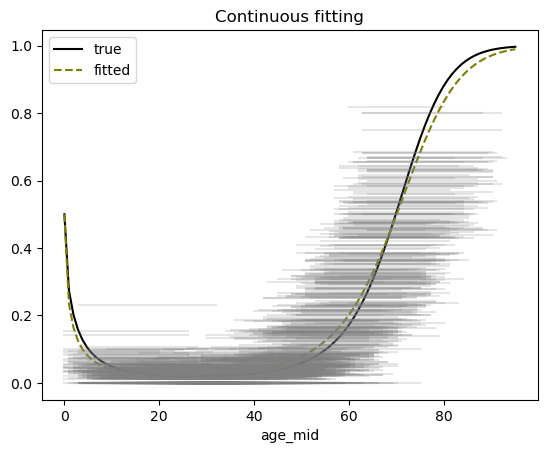

In [34]:
df_pred_cont = pd.DataFrame(
    dict(age_mid=np.linspace(low_age, high_age, 101))
)
df_pred_cont["cov1"] = func1(df_pred_cont["age_mid"])
df_pred_cont["cov2"] = func2(df_pred_cont["age_mid"])
df_pred_cont["cov3"] = func3(df_pred_cont["age_mid"])
df_pred_cont = model_cont.predict(df_pred_cont)
df_pred_cont["p_true"] = expit_death_rate_function(df_pred_cont["age_mid"], c1=c1)

fig, ax = plt.subplots()
ax.plot(df_pred_cont["age_mid"], df_pred_cont["p_true"], color="k", label="true")
ax.plot(df_pred_cont["age_mid"], df_pred_cont["p"], color="olive", linestyle="--", label="fitted")
ax.legend()
ax.set_xlabel("age_mid")
plt.title("Continuous fitting")

for _, row in df.iterrows():
    ax.plot([row["age_start"], row["age_end"]], [row["obs"]]*2, color="grey", alpha=0.2)

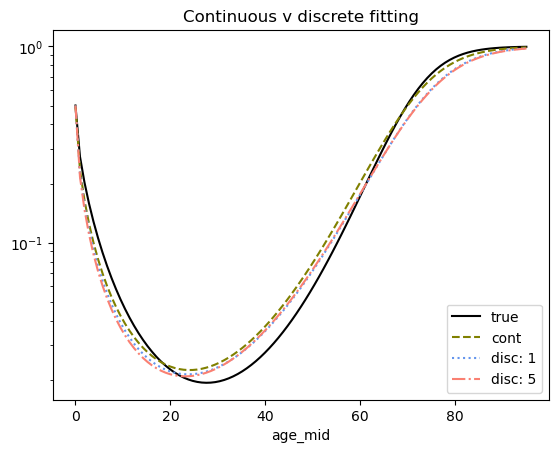

In [41]:
fig, ax = plt.subplots()
ax.plot(df_pred_cont["age_mid"], df_pred_cont["p_true"], color="k", label="true")
ax.plot(df_pred_cont["age_mid"], df_pred_cont["p"], color="olive", linestyle="--", label="cont")
ax.plot(df_pred["age_mid"], df_pred["p"], color="cornflowerblue", linestyle="dotted", label="disc: 1")
ax.plot(df_pred["age_mid"], df_pred5["p"], color="salmon", linestyle="dashdot", label="disc: 5")
ax.legend()
ax.set_xlabel("age_mid")
plt.title("Continuous v discrete fitting")
plt.yscale("log")

# for _, row in df.iterrows():
#     ax.plot([row["age_start"], row["age_end"]], [row["obs"]]*2, color="grey", alpha=0.2)

In [36]:
print(f"This is the MSE for discrete-uniform fitting with 1 spacing: {mean_squared_error(df_pred["p"], df_pred["p_true"])}")
print(f"This is the MSE for discrete-uniform fitting with 5 spacing: {mean_squared_error(df_pred5["p"], df_pred["p_true"])}")
print(f"This is the MSE for continuous fitting: {mean_squared_error(df_pred_cont["p"], df_pred["p_true"])}")

This is the MSE for discrete-uniform fitting with 1 spacing: 0.0022920921277272736
This is the MSE for discrete-uniform fitting with 5 spacing: 0.0026134179483737756
This is the MSE for continuous fitting: 0.00048637993449083454


In [37]:
print(f"This is the MAE for discrete-uniform fitting with 1 spacing: {mean_absolute_error(df_pred["p"], df_pred["p_true"])}")
print(f"This is the MAE for discrete-uniform fitting with 5 spacing: {mean_absolute_error(df_pred5["p"], df_pred["p_true"])}")
print(f"This is the MAE for continuous fitting: {mean_absolute_error(df_pred_cont["p"], df_pred["p_true"])}")

This is the MAE for discrete-uniform fitting with 1 spacing: 0.03061279430525206
This is the MAE for discrete-uniform fitting with 5 spacing: 0.03296803792912533
This is the MAE for continuous fitting: 0.017447987808207804
